# 6,067 parcelas. Tres ecosistemas. Solo uno le sigue el paso al calentamiento.

Bosques, praderas y cumbres alpinas en toda Europa. Décadas de re-visitas. Las comunidades vegetales se están "termofilizando" — las especies de climas cálidos ganan terreno. Pero no a la misma velocidad.

---

**Paper:** Yue, K. et al. (2025). Divergent thermophilization trajectories across European ecosystems. *Nature.*
DOI: [10.1038/s41586-025-09622-7](https://doi.org/10.1038/s41586-025-09622-7)

**Datos:** [Figshare — CC BY 4.0](https://doi.org/10.6084/m9.figshare.28368743) (6,067 parcelas, 163 sitios, 3 ecosistemas)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-24-termofilizacion-cumbres-alpinas/notebook.ipynb)

▶️ [Ver el video](https://youtube.com/watch?v=eKxXV4bGJzY)

## ¿Qué es la termofilización?

Cuando el clima se calienta, las especies que prefieren calor se expanden y las de frío retroceden. La composición de una comunidad vegetal se "calienta" — eso es **termofilización**.

Pero si las plantas cambian más lento que el clima, se acumula una **deuda climática**: la comunidad debería ser más cálida de lo que es. Cuanto mayor la deuda, mayor el desajuste entre plantas y clima.

Los datos cubren 6,067 parcelas de vegetación en Europa — algunas con hasta 78 años entre visitas — en bosques, praderas y cumbres alpinas.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FUENTE = 'Fuente: Yue et al. (2025), Nature | Datos: Figshare (CC BY 4.0)'
COLOR_BOSQUE = '#059669'    # Emerald
COLOR_PRADERA = '#D97706'   # Amber
COLOR_CUMBRE = '#2563EB'    # Azul CaM
COLOR_CERO = '#DC2626'      # Rojo

COLORES = {'forest': COLOR_BOSQUE, 'grassland': COLOR_PRADERA, 'summit': COLOR_CUMBRE}
NOMBRES = {'forest': 'Bosques', 'grassland': 'Praderas', 'summit': 'Cumbres alpinas'}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Cargar estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datos
resumen = pd.read_csv('datos/termofilizacion_resumen.csv')
deuda = pd.read_csv('datos/deuda_climatica_resumen.csv')
parcelas = pd.read_csv('datos/parcelas.csv')

print(f"Parcelas: {len(parcelas)}")
print(f"  Bosques: {(parcelas['ecosystem'] == 'forest').sum()}")
print(f"  Praderas: {(parcelas['ecosystem'] == 'grassland').sum()}")
print(f"  Cumbres: {(parcelas['ecosystem'] == 'summit').sum()}")
print(f"Sitios: {parcelas['site'].nunique()}")

Parcelas: 6067
  Bosques: 4372
  Praderas: 1209
  Cumbres: 486
Sitios: 163


## Aquí está.

La termofilización de las especies más frías (percentil 5) — donde se ve la mayor diferencia entre ecosistemas.

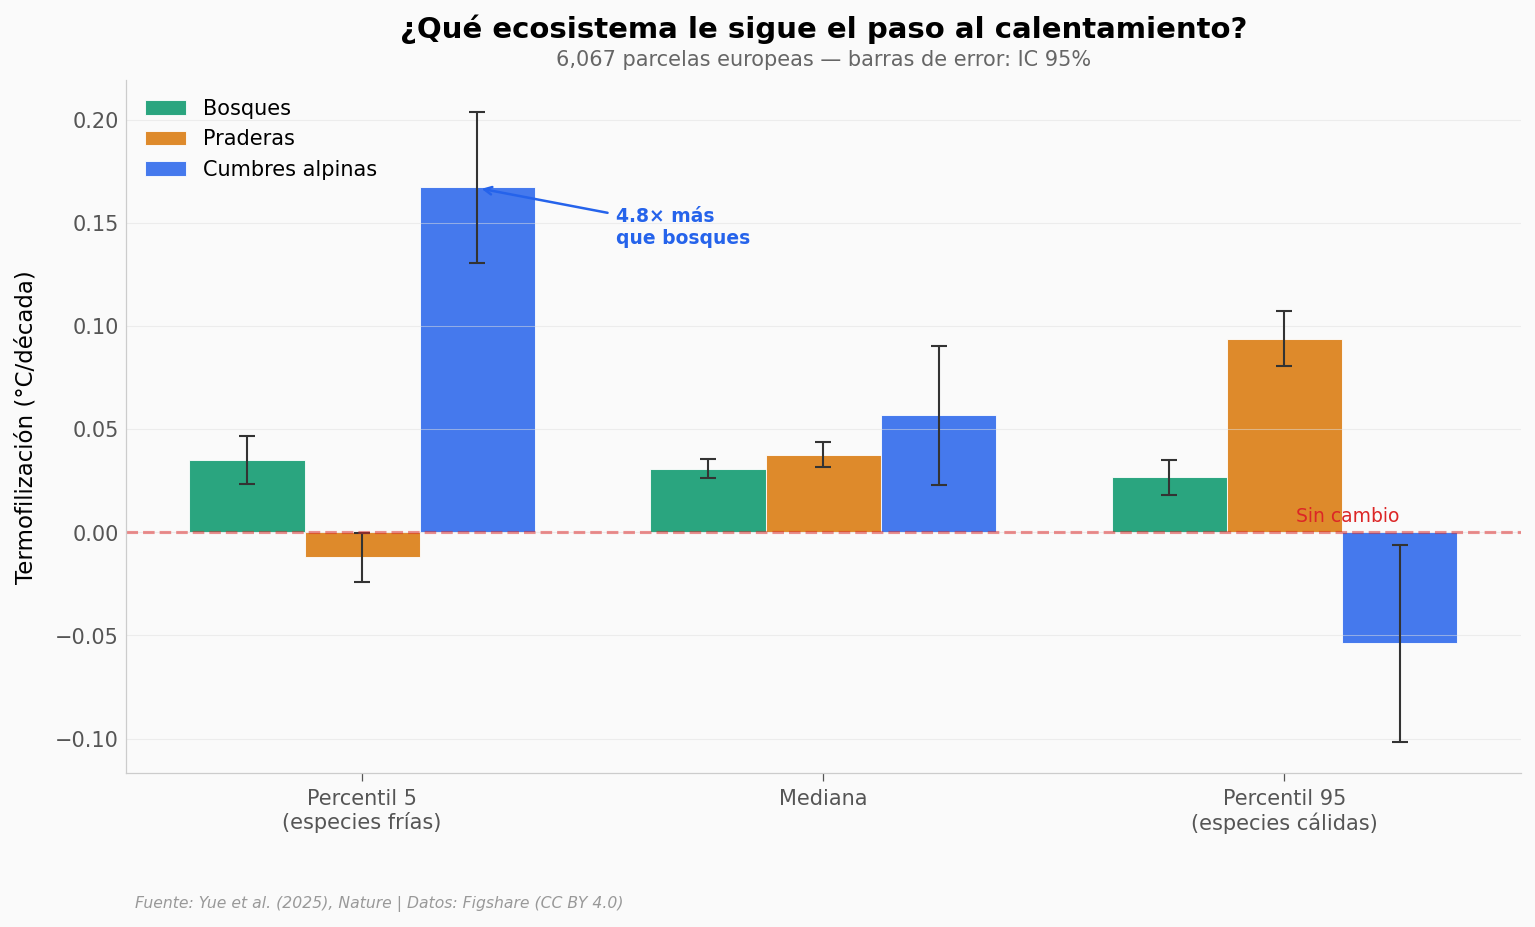

In [2]:
fig, ax = plt.subplots(figsize=(12, 6))

metricas = ['05', 'Median', '95']
labels_met = ['Percentil 5\n(especies frías)', 'Mediana', 'Percentil 95\n(especies cálidas)']
ecosistemas = ['forest', 'grassland', 'summit']
width = 0.25

for i, eco in enumerate(ecosistemas):
    sub = resumen[resumen['ecosistema'] == eco]
    vals = [sub[sub['metrica'] == m]['media'].values[0] for m in metricas]
    ses = [sub[sub['metrica'] == m]['se'].values[0] * 1.96 for m in metricas]
    x = np.arange(len(metricas)) + i * width
    ax.bar(x, vals, width, color=COLORES[eco], alpha=0.85, label=NOMBRES[eco],
           edgecolor='white', linewidth=0.5)
    ax.errorbar(x, vals, yerr=ses, fmt='none', color='#333333',
                capsize=4, capthick=1, linewidth=1)

ax.axhline(y=0, color=COLOR_CERO, linewidth=1.5, linestyle='--', alpha=0.5)
ax.text(2.5, 0.005, 'Sin cambio', fontsize=9, color=COLOR_CERO, ha='right')

ax.set_xticks(np.arange(len(metricas)) + width)
ax.set_xticklabels(labels_met, fontsize=10)
ax.set_ylabel('Termofilización (°C/década)', fontsize=11)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)

ax.set_title('¿Qué ecosistema le sigue el paso al calentamiento?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '6,067 parcelas europeas — barras de error: IC 95%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Annotate the 4.8x ratio
ax.annotate('4.8× más\nque bosques',
            xy=(0 + 2*width, 0.167), xytext=(0.8, 0.14),
            fontsize=9, fontweight='bold', color=COLOR_CUMBRE,
            arrowprops=dict(arrowstyle='->', color=COLOR_CUMBRE, lw=1.2))

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/termofilizacion_ecosistemas.png', dpi=200, bbox_inches='tight')
plt.show()

Las cumbres alpinas (azul) muestran termofilización **4.8 veces mayor** que los bosques en las especies más frías (percentil 5). Pero miremos las columnas de la derecha: en el percentil 95 (especies cálidas), las cumbres van *negativas* — están perdiendo especies cálidas mientras ganan frías.

Los bosques y praderas muestran termofilización positiva en todas las métricas, pero los valores son cercanos a cero. La comunidad vegetal cambia, pero no al ritmo del clima.

¿Cuánta deuda han acumulado?

## La deuda climática

Si las plantas no siguen al clima, se acumula una "deuda". Cuanto mayor el número, mayor el desajuste.

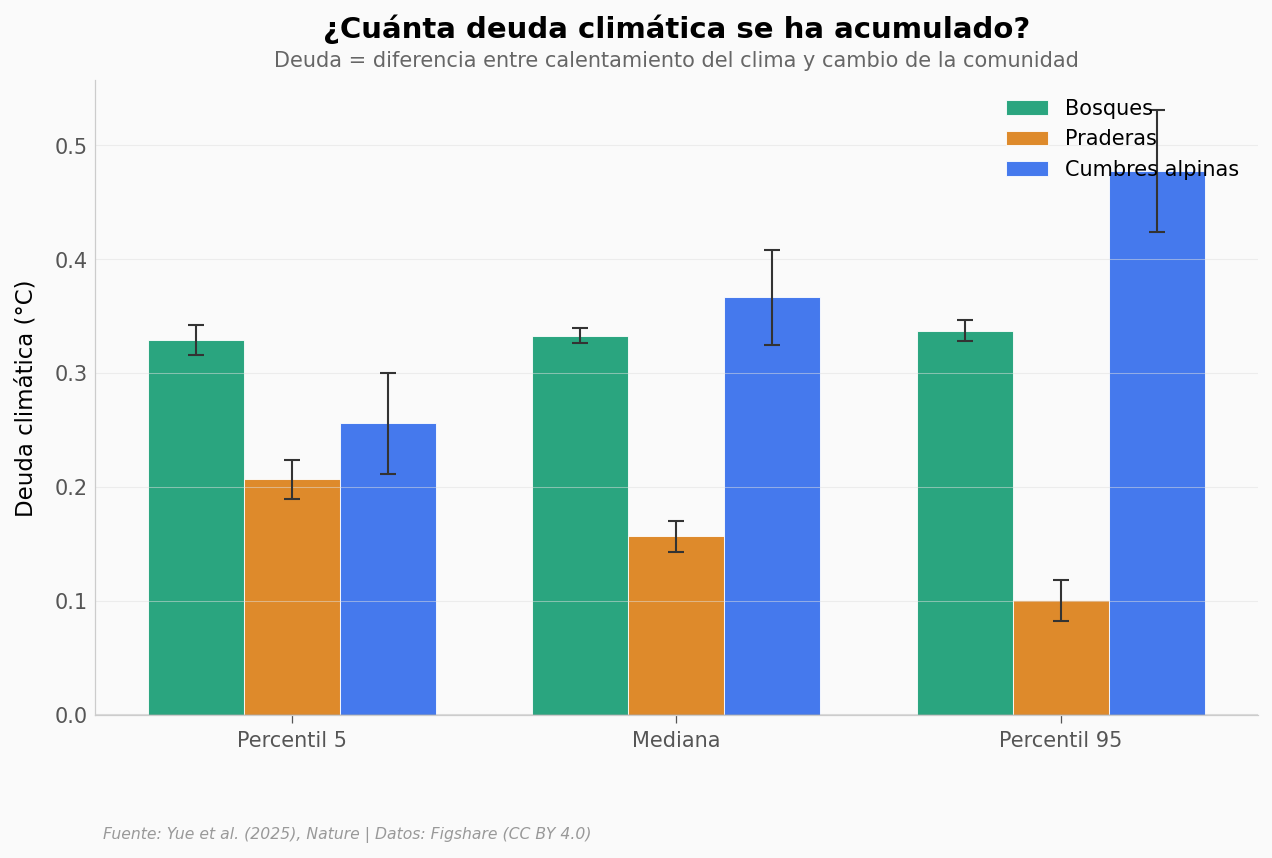

In [3]:
fig, ax = plt.subplots(figsize=(10, 5.5))

metricas_d = ['05', 'Median', '95']
labels_d = ['Percentil 5', 'Mediana', 'Percentil 95']

for i, eco in enumerate(ecosistemas):
    sub = deuda[deuda['ecosistema'] == eco]
    vals = [sub[sub['metrica'] == m]['media'].values[0] for m in metricas_d]
    ses = [sub[sub['metrica'] == m]['se'].values[0] * 1.96 for m in metricas_d]
    x = np.arange(len(metricas_d)) + i * width
    ax.bar(x, vals, width, color=COLORES[eco], alpha=0.85, label=NOMBRES[eco],
           edgecolor='white', linewidth=0.5)
    ax.errorbar(x, vals, yerr=ses, fmt='none', color='#333333',
                capsize=4, capthick=1, linewidth=1)

ax.axhline(y=0, color='#999999', linewidth=1, linestyle='-', alpha=0.3)
ax.set_xticks(np.arange(len(metricas_d)) + width)
ax.set_xticklabels(labels_d, fontsize=10)
ax.set_ylabel('Deuda climática (°C)', fontsize=11)
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

ax.set_title('¿Cuánta deuda climática se ha acumulado?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Deuda = diferencia entre calentamiento del clima y cambio de la comunidad',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/deuda_climatica.png', dpi=200, bbox_inches='tight')
plt.show()

Bosques y cumbres alpinas acumulan deuda climática similar (~0.33-0.37°C), pero por razones opuestas:
- **Bosques:** los árboles viven décadas — la comunidad cambia lento
- **Cumbres:** las especies frías retroceden, pero no hay especies cálidas que las reemplacen a esa altitud

Las praderas tienen menos deuda (0.16°C) — las hierbas tienen ciclos de vida más cortos y responden más rápido.

¿Cómo se ve la distribución parcela por parcela?

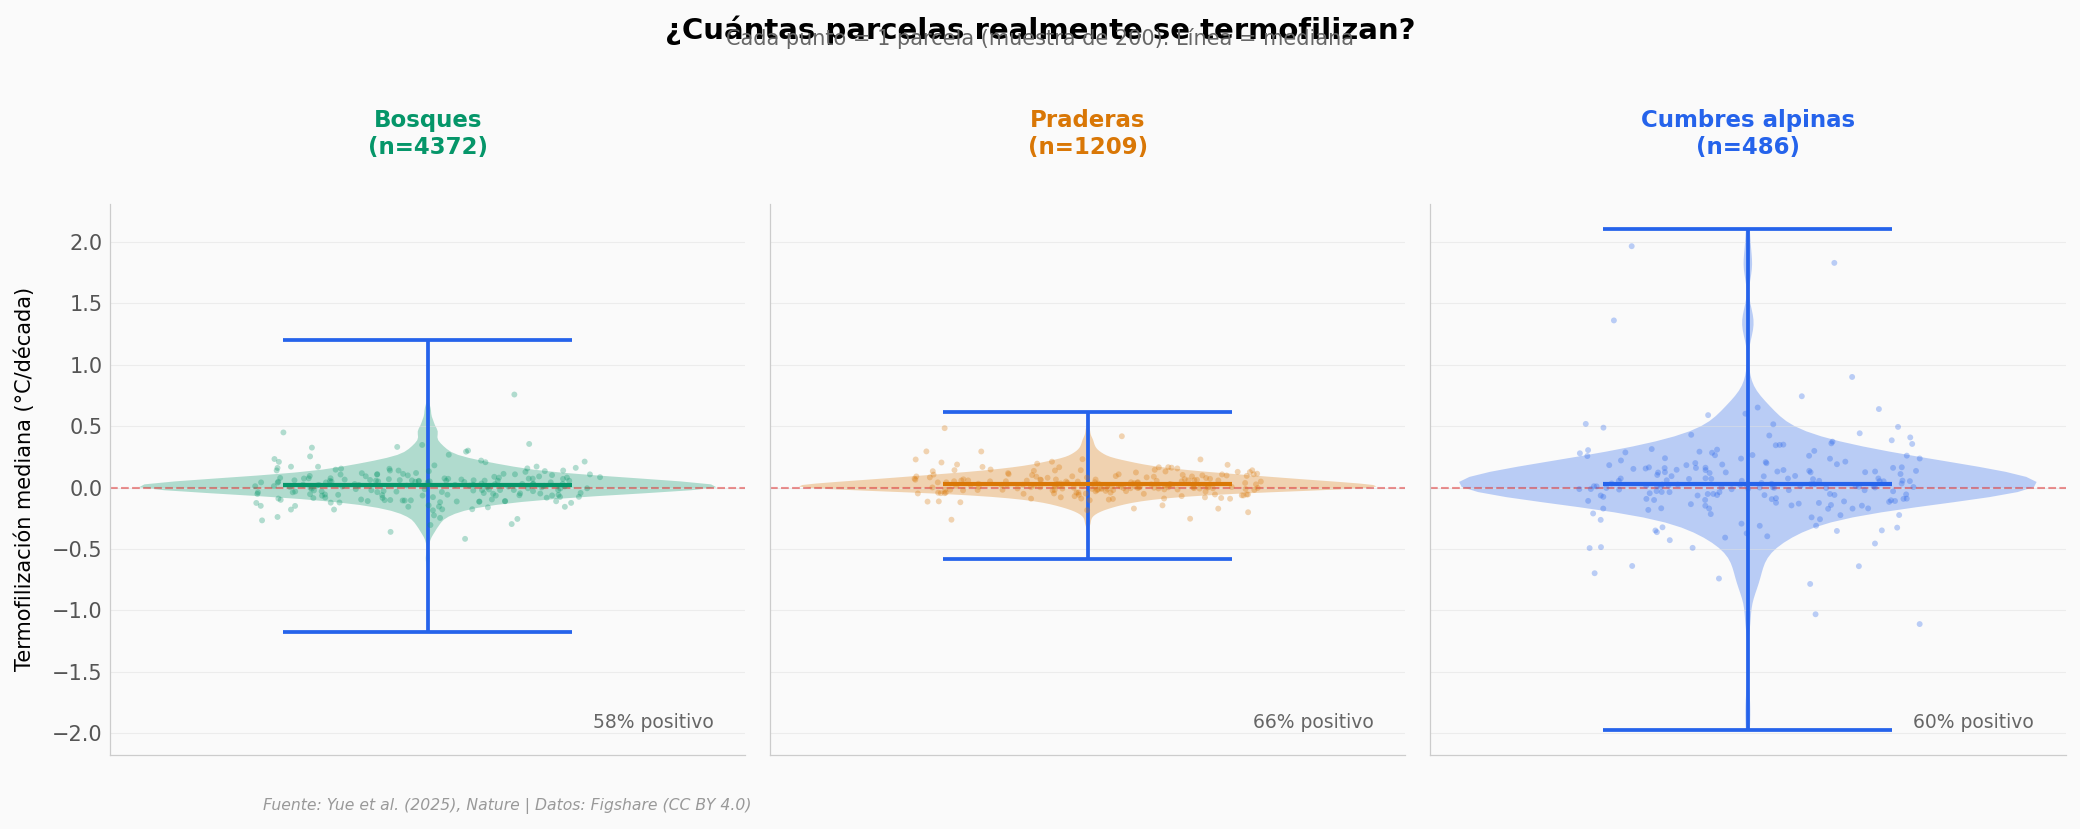

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for i, eco in enumerate(ecosistemas):
    ax = axes[i]
    sub = parcelas[parcelas['ecosystem'] == eco]['ThermGSMedian_abundance'].dropna()
    
    parts = ax.violinplot([sub.values], positions=[0], showmedians=True,
                          showmeans=False)
    for pc in parts['bodies']:
        pc.set_facecolor(COLORES[eco])
        pc.set_alpha(0.3)
    parts['cmedians'].set_color(COLORES[eco])
    parts['cmedians'].set_linewidth(2)
    
    # Scatter subsample
    np.random.seed(42)
    sample = sub.sample(min(200, len(sub)))
    jitter = np.random.uniform(-0.15, 0.15, len(sample))
    ax.scatter(jitter, sample.values, color=COLORES[eco], s=8, alpha=0.3,
               edgecolors='none', zorder=3)
    
    ax.axhline(y=0, color=COLOR_CERO, linewidth=1, linestyle='--', alpha=0.5)
    ax.set_title(f'{NOMBRES[eco]}\n(n={len(sub)})', fontsize=11,
                 fontweight='bold', color=COLORES[eco])
    ax.set_xticks([])
    
    # Stats
    pct_pos = (sub > 0).mean() * 100
    ax.text(0.95, 0.05, f'{pct_pos:.0f}% positivo',
            transform=ax.transAxes, fontsize=9, ha='right', color='#666666')

axes[0].set_ylabel('Termofilización mediana (°C/década)', fontsize=10)

fig.suptitle('¿Cuántas parcelas realmente se termofilizan?',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.98, 'Cada punto = 1 parcela (muestra de 200). Línea = mediana',
         fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/distribucion_parcelas.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan fuera de rango están las cumbres?

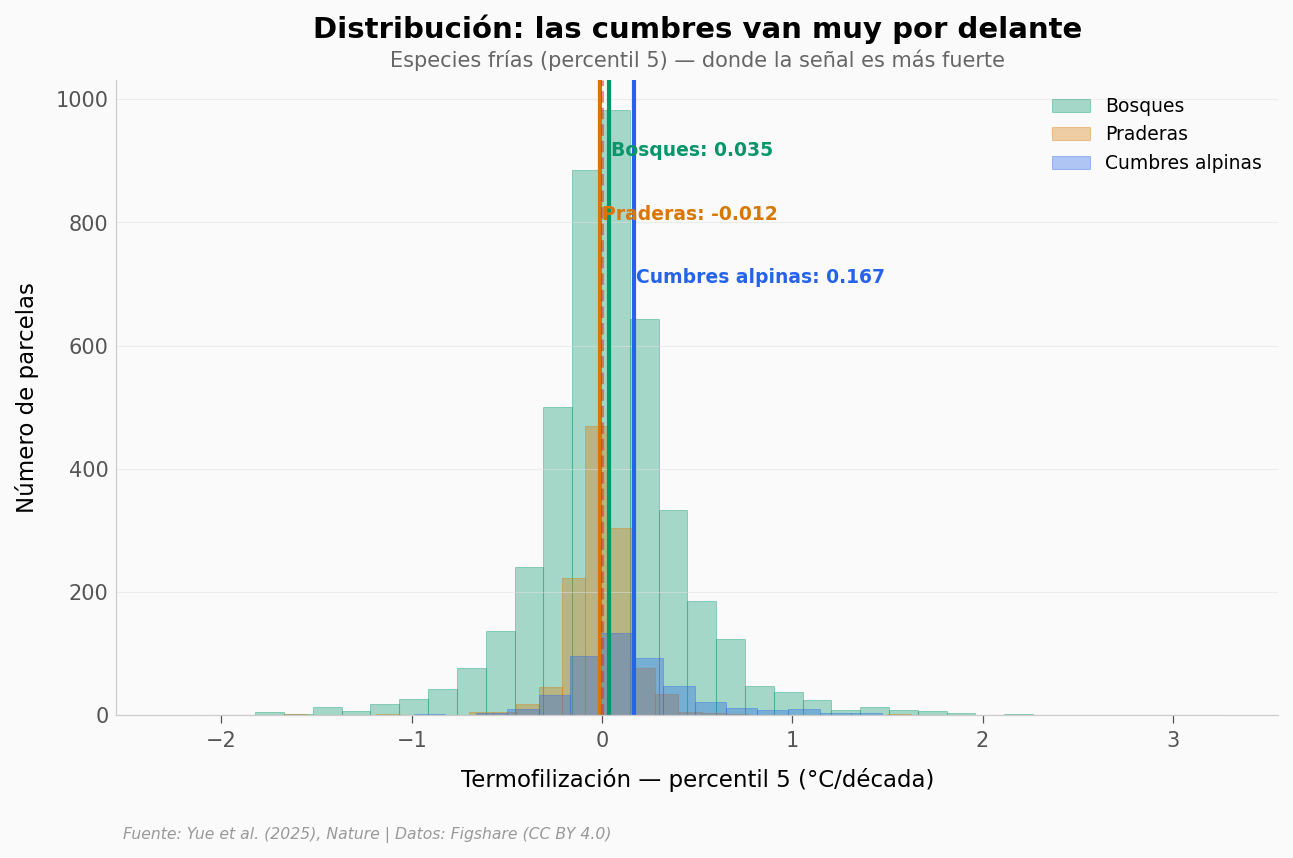

Bosques: 54% parcelas con termofilización positiva (P5)
Praderas: 48% parcelas con termofilización positiva (P5)
Cumbres alpinas: 69% parcelas con termofilización positiva (P5)


In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for eco in ecosistemas:
    sub = parcelas[parcelas['ecosystem'] == eco]['ThermGS05_abundance'].dropna()
    ax.hist(sub.values, bins=30, color=COLORES[eco], alpha=0.35,
            edgecolor=COLORES[eco], linewidth=0.5, label=NOMBRES[eco])

# Vertical lines at means
for eco in ecosistemas:
    mean_val = parcelas[parcelas['ecosystem'] == eco]['ThermGS05_abundance'].mean()
    ax.axvline(x=mean_val, color=COLORES[eco], linewidth=2, linestyle='-')
    label_y = {'forest': 0.88, 'grassland': 0.78, 'summit': 0.68}
    ax.text(mean_val + 0.01, ax.get_ylim()[1] * label_y[eco],
            f'{NOMBRES[eco]}: {mean_val:.3f}',
            fontsize=9, fontweight='bold', color=COLORES[eco])

ax.axvline(x=0, color=COLOR_CERO, linewidth=1.5, linestyle='--', alpha=0.5)

ax.set_xlabel('Termofilización — percentil 5 (°C/década)', fontsize=11)
ax.set_ylabel('Número de parcelas', fontsize=11)
ax.set_title('Distribución: las cumbres van muy por delante',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Especies frías (percentil 5) — donde la señal es más fuerte',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_termofilizacion.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats
for eco in ecosistemas:
    sub = parcelas[parcelas['ecosystem'] == eco]['ThermGS05_abundance']
    pct_pos = (sub > 0).mean() * 100
    print(f"{NOMBRES[eco]}: {pct_pos:.0f}% parcelas con termofilización positiva (P5)")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las cumbres alpinas muestran termofilización hasta 5x mayor | ✅ | Percentil 5 (especies frías): summit 0.167 vs forest 0.035 = 4.8x (Cohen's d = 0.34, n = 486 vs 4372). La mediana es menor (1.8x) — el "5x" aplica a la cola fría |
| Bosques y praderas muestran termofilización positiva pero no significativamente distinta de cero | ⚠️ | Nuestro Wilcoxon da p << 0.001 para bosques (n = 4372) y praderas (n = 1209). Shapiro-Wilk rechaza normalidad en los 3 ecosistemas (p < 1e-20). El paper usa modelos bayesianos con efectos aleatorios por sitio — un test más conservador. Con n tan grande, incluso efectos minúsculos son "significativos" |
| Las cumbres tienen mayor deuda climática que praderas | ✅ | Cumbres: 0.37°C vs praderas: 0.16°C. Bosques similar a cumbres (0.33°C) |
| La deuda correlaciona con la temperatura baseline | ⚠️ | Spearman ρ = 0.13 (cumbres, p = 0.004, n = 486), ρ = −0.09 (bosques, p < 0.001, n = 4372). Nota: el paper reporta correlación con *cambio* de T (delta-T), no con T baseline — nuestros datos no incluyen delta-T. Correlaciones débiles en ambos casos |

> **Limitaciones:** (1) Datos son promedios por parcela — no hay series temporales dentro de cada parcela. (2) El rango temporal varía enormemente (12-78 años). (3) Las métricas dependen del percentil elegido — el "5x" solo aplica al P5, no a la mediana. (4) Sin test formal de diferencia entre ecosistemas en nuestro análisis (el paper usa modelos bayesianos).

## Ahora tú

1. **¿Importa la temperatura baseline?** Las cumbres son más frías (media 9.3°C) que bosques (13.9°C). ¿Las parcelas más frías dentro de cada ecosistema se termofilizan más?

2. **¿Y si solo miras el percentil 95 (especies cálidas)?** Las cumbres van negativas ahí — ¿están *perdiendo* diversidad cálida? Grafica `ThermGS95_abundance` para ver.

3. **¿Hay sitios outlier?** Algunas parcelas muestran termofilización >0.5°C/década. ¿Son de sitios específicos?

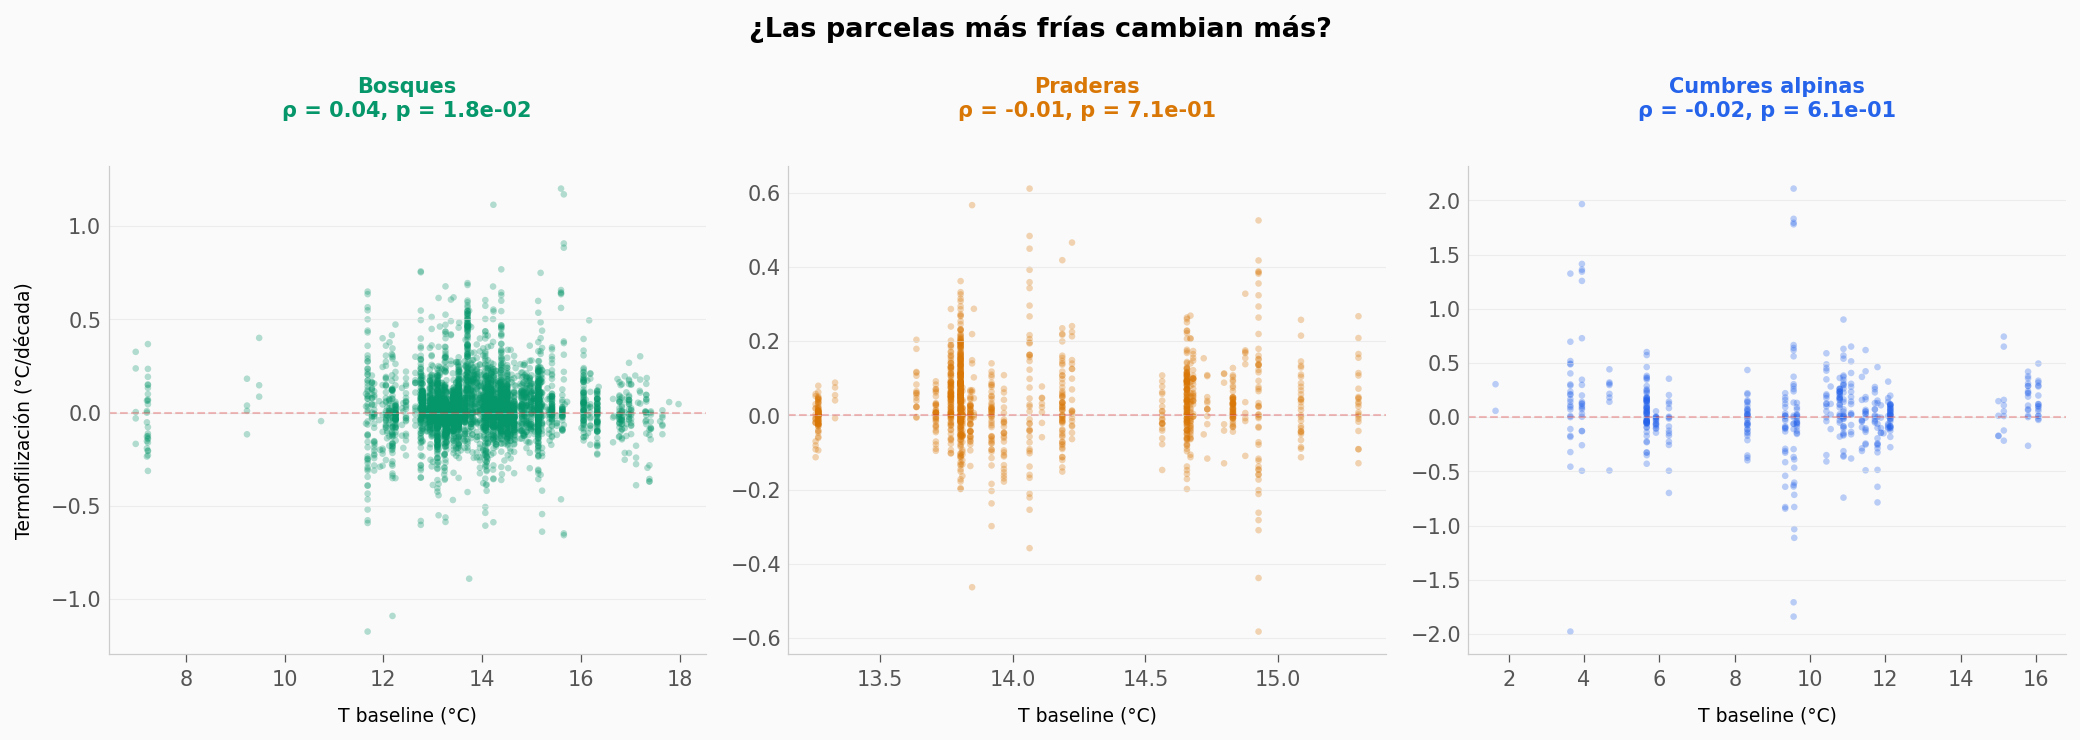

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Las parcelas más frías se termofilizan más?

from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, eco in enumerate(ecosistemas):
    ax = axes[i]
    sub = parcelas[parcelas['ecosystem'] == eco].dropna(
        subset=['Tmean_GS_B_CRU', 'ThermGSMedian_abundance'])
    
    ax.scatter(sub['Tmean_GS_B_CRU'], sub['ThermGSMedian_abundance'],
               color=COLORES[eco], s=10, alpha=0.3, edgecolors='none')
    
    rho, p = stats.spearmanr(sub['Tmean_GS_B_CRU'], sub['ThermGSMedian_abundance'])
    ax.set_title(f'{NOMBRES[eco]}\nρ = {rho:.2f}, p = {p:.1e}',
                 fontsize=10, color=COLORES[eco], fontweight='bold')
    ax.set_xlabel('T baseline (°C)', fontsize=9)
    ax.axhline(y=0, color=COLOR_CERO, linewidth=1, linestyle='--', alpha=0.3)

axes[0].set_ylabel('Termofilización (°C/década)', fontsize=9)
fig.suptitle('¿Las parcelas más frías cambian más?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figuras/temp_vs_termofilizacion.png', dpi=200, bbox_inches='tight')
plt.show()

---

### Créditos

- **Paper:** Yue, K. et al. (2025). Divergent thermophilization trajectories across European ecosystems. *Nature.*
- **DOI:** [10.1038/s41586-025-09622-7](https://doi.org/10.1038/s41586-025-09622-7)
- **Datos:** [Figshare (CC BY 4.0)](https://doi.org/10.6084/m9.figshare.28368743)
- **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)